## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../../../Mamoth")
sys.path.insert(0, "../../../../Modules")

from utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [5]:
mosquito_data.nuts2.unique()

array(['κεντρικης μακεδονιας', 'θεσσαλιας', 'κρητης', 'δυτικης ελλαδας'],
      dtype=object)

In [6]:
mosquito_data_nuts2 = mosquito_data.query(f"nuts2 == '{NUTS2_EL}'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [7]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [8]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

# columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
#                 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                 'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
#                 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
#                 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week',
#                 'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

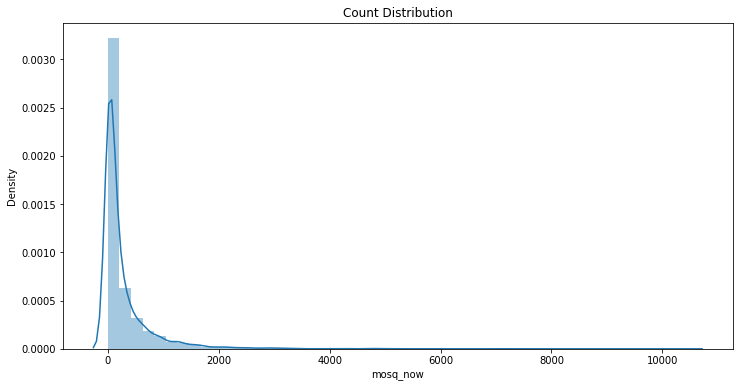

In [9]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [10]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

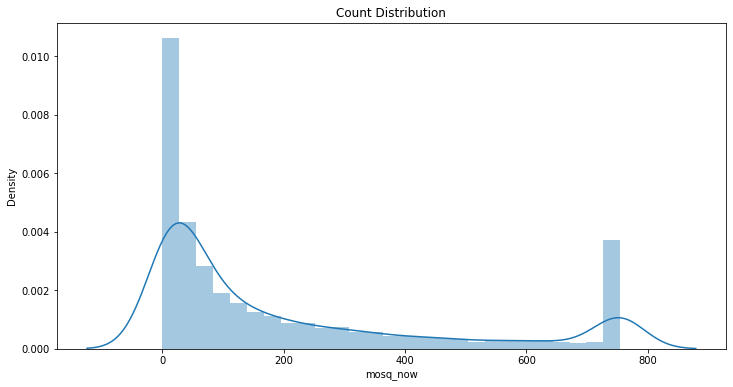

In [11]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

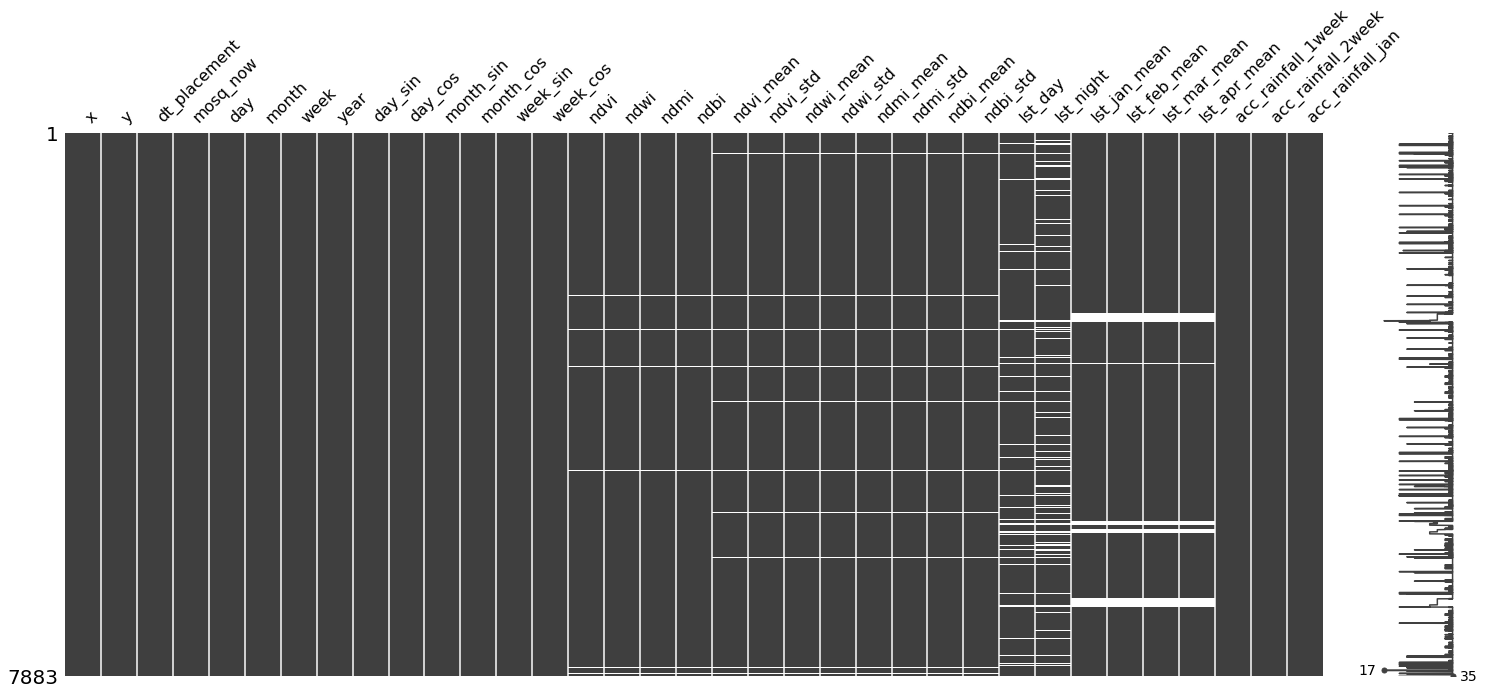

In [12]:
missingno.matrix(mosquito_data_nuts2)

In [13]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

# features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                         'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
#                         'lst_day', 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [14]:
# imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
#                    'lst_day','lst_night']

imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

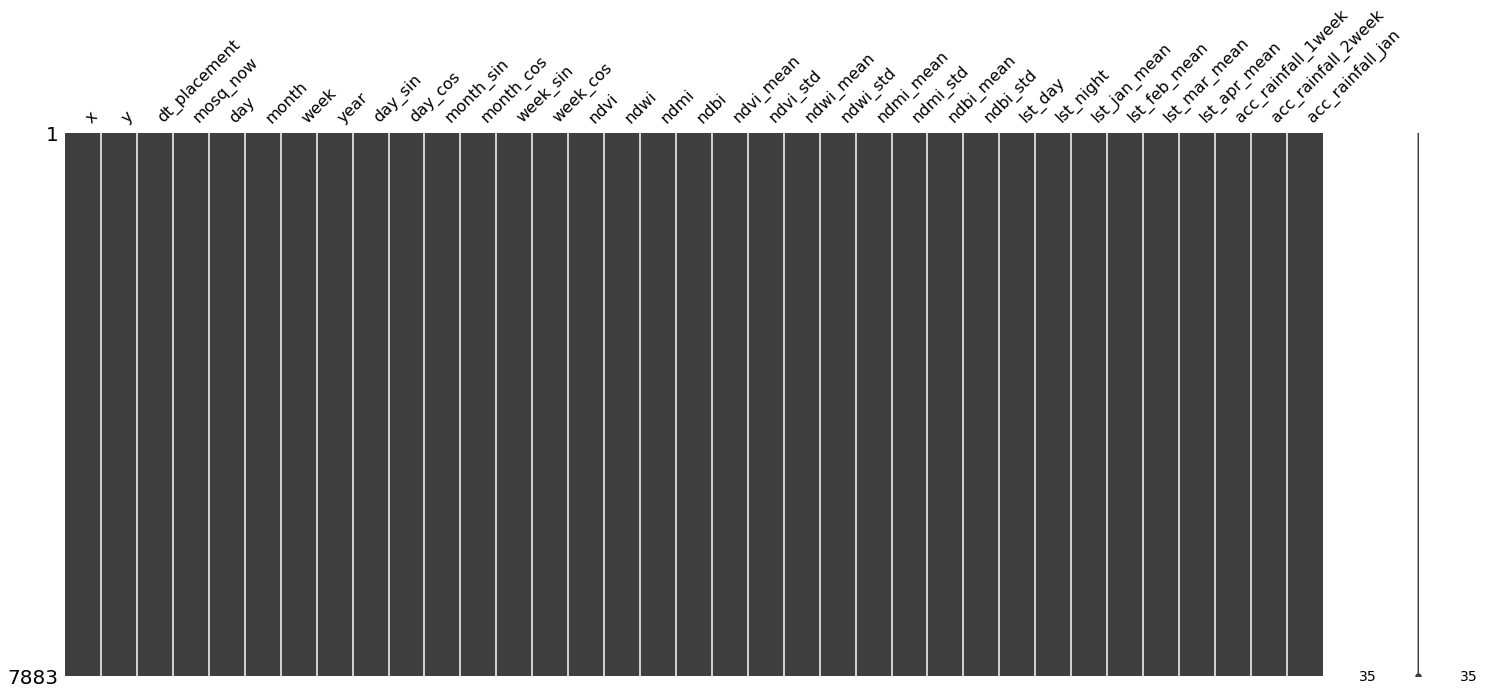

In [15]:
missingno.matrix(mosquito_data_nuts2)

In [16]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [17]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [18]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 19.26871 | Val Loss: 25.16690 | Train Acc: 2.607| Val Acc: 2.069
Epoch 002: | Train Loss: 18.85865 | Val Loss: 26.44855 | Train Acc: 2.302| Val Acc: 2.087
Epoch 003: | Train Loss: 18.37672 | Val Loss: 25.73500 | Train Acc: 2.195| Val Acc: 2.076
Epoch 004: | Train Loss: 17.97638 | Val Loss: 26.38235 | Train Acc: 2.133| Val Acc: 2.095
Epoch 005: | Train Loss: 17.84687 | Val Loss: 24.72440 | Train Acc: 2.109| Val Acc: 1.969
Epoch 006: | Train Loss: 17.50499 | Val Loss: 24.43615 | Train Acc: 2.036| Val Acc: 1.968
Epoch 007: | Train Loss: 17.31731 | Val Loss: 24.27260 | Train Acc: 2.040| Val Acc: 1.981
Epoch 008: | Train Loss: 17.12694 | Val Loss: 24.43066 | Train Acc: 1.994| Val Acc: 1.990
Epoch 009: | Train Loss: 16.83035 | Val Loss: 24.03061 | Train Acc: 1.990| Val Acc: 1.971
Epoch 010: | Train Loss: 16.80632 | Val Loss: 24.09471 | Train Acc: 1.981| Val Acc: 1.987
Epoch 011: | Train Loss: 16.75847 | Val Loss: 24.04025 | Train Acc: 2.003| Val Acc: 1.987
Epoch 012:

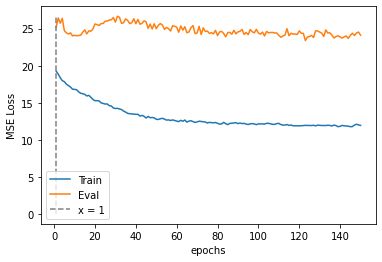

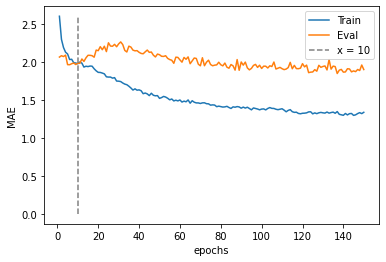

In [19]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [20]:
metrics(train, test, threshold=30)

MAE on train set:  138.07076447854203
min prediction: 1
max prediction: 1298

MAE on test set:  149.63828574105239
Error ⩽ 30: 24.05 %
min prediction: 1
max prediction: 962


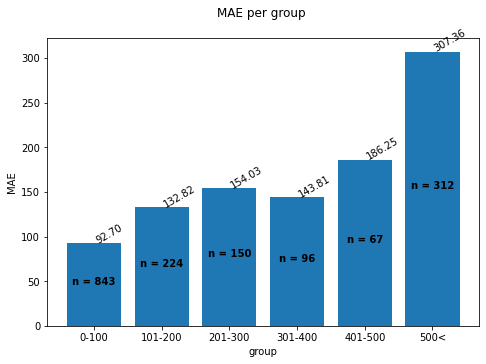

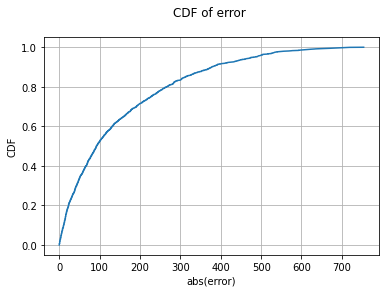

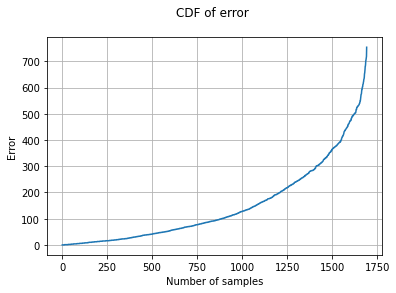

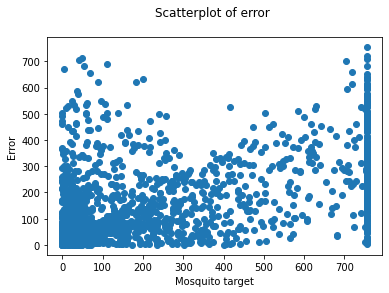

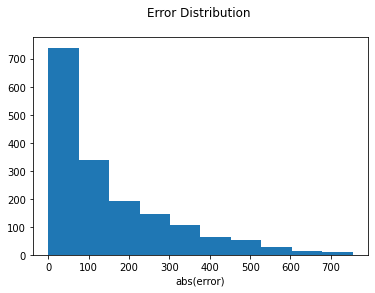

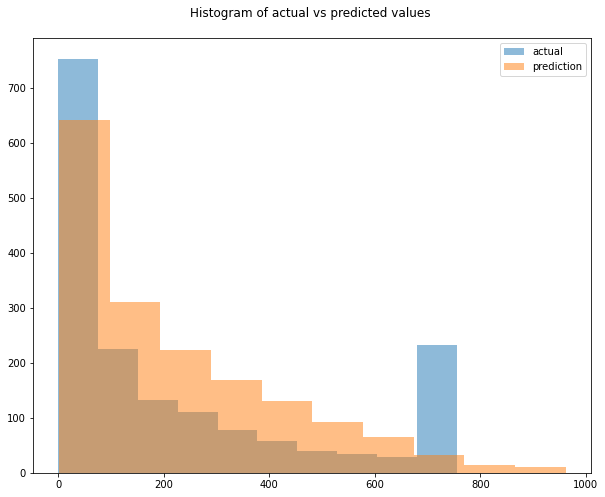

In [21]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.89359 | Val Loss: 1.04378 | Train Acc: 1.596| Val Acc: 0.633
Epoch 002: | Train Loss: 13.79096 | Val Loss: 0.98798 | Train Acc: 1.579| Val Acc: 0.633
Epoch 003: | Train Loss: 13.53186 | Val Loss: 3.06615 | Train Acc: 1.560| Val Acc: 1.633
Epoch 004: | Train Loss: 13.28548 | Val Loss: 3.08242 | Train Acc: 1.514| Val Acc: 1.633
Epoch 005: | Train Loss: 13.35618 | Val Loss: 4.11752 | Train Acc: 1.532| Val Acc: 1.633
Epoch 006: | Train Loss: 13.08261 | Val Loss: 4.35655 | Train Acc: 1.499| Val Acc: 1.633
Epoch 007: | Train Loss: 13.05106 | Val Loss: 4.32465 | Train Acc: 1.486| Val Acc: 1.633
Epoch 008: | Train Loss: 13.02931 | Val Loss: 1.28407 | Train Acc: 1.500| Val Acc: 1.633
Epoch 009: | Train Loss: 12.99468 | Val Loss: 3.75861 | Train Acc: 1.484| Val Acc: 1.633
Epoch 010: | Train Loss: 13.00488 | Val Loss: 2.30977 | Train Acc: 1.495| Val Acc: 1.633
Epoch 011: | Train Loss: 13.07015 | Val Loss: 3.36997 | Train Acc: 1.499| Val Acc: 1.633
Epoch 012: | Train Lo

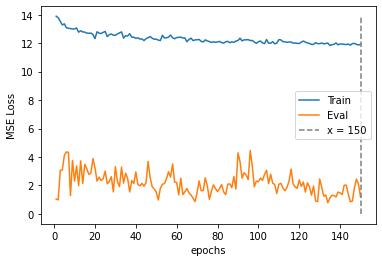

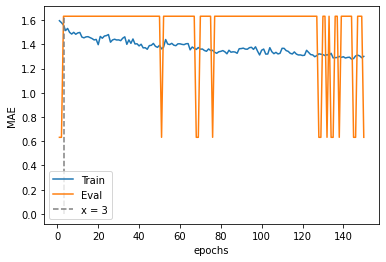

In [22]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [23]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'wb'))